In [29]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform

# ---------- utilities ----------

def step_lengths(curve):
    return np.linalg.norm(np.diff(curve, axis=0), axis=1)


def diameter(curve):
    return np.max(pdist(curve))

def radius_of_gyration(curve):
    center = np.mean(curve, axis=0)
    return np.sqrt(np.mean(np.sum((curve - center)**2, axis=1)))

def discrete_curvature(curve):
    v1 = curve[1:-1] - curve[:-2]
    v2 = curve[2:] - curve[1:-1]
    
    norms = np.linalg.norm(v1, axis=1) * np.linalg.norm(v2, axis=1)
    dot = np.sum(v1 * v2, axis=1)
    
    cos_angle = np.clip(dot / (norms + 1e-8), -1, 1)
    angles = np.arccos(cos_angle)
    return angles

def curvature_stats(curve):
    curv = discrete_curvature(curve)
    return np.min(curv), np.max(curv), np.mean(curv)

def distortion(curve):
    # intrinsic distance = shortest path along curve
    d_intrinsic = np.cumsum(np.insert(step_lengths(curve), 0, 0))
    
    D_intrinsic = np.abs(d_intrinsic[:, None] - d_intrinsic[None, :])
    D_extrinsic = squareform(pdist(curve))
    
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = D_intrinsic / (D_extrinsic + 1e-8)
    
    return np.nanmax(ratio)

In [33]:
def compute_baseline_df(dataset="zebrafish"):

    records = []

    for label in ["biased", "unbiased", "zebrafish"]:
        i = 1
        while True:
            fname = f"{label}_{i}"
            try:
                curve = np.load(f"{dataset}/pointClouds/{fname}.npy")
            except:
                break

            min_c, max_c, avg_c = curvature_stats(curve)

            records.append({
                "Name": fname,
                "Type": label,
                "Diameter": diameter(curve),
                "ROG": radius_of_gyration(curve),
                "Distortion": distortion(curve),
                "Curv_min": min_c,
                "Curv_max": max_c,
                "Curv_mean": avg_c
            })

            i += 1

    return pd.DataFrame(records)

Df_baseline = compute_baseline_df()

/var/folders/mw/7v7jv8pd66q0t8myw8z65h280000gn/T/ipykernel_89779/4160835073.py:19: RuntimeWarning:

invalid value encountered in subtract

/var/folders/mw/7v7jv8pd66q0t8myw8z65h280000gn/T/ipykernel_89779/4160835073.py:20: RuntimeWarning:

invalid value encountered in subtract

/var/folders/mw/7v7jv8pd66q0t8myw8z65h280000gn/T/ipykernel_89779/4160835073.py:16: RuntimeWarning:

invalid value encountered in subtract

/opt/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:1452: RuntimeWarning:

invalid value encountered in subtract



In [34]:
D

              Name       Type   Diameter       ROG  Distortion  Curv_min  \
0         biased_1     biased  10.336643  3.542802   11.610800  0.082350   
1         biased_2     biased   6.168264  1.912538   15.386434  0.351850   
2         biased_3     biased  10.416716  3.331693    4.119397  0.102617   
3         biased_4     biased   4.672902  1.495469   72.393424  0.066959   
4         biased_5     biased   7.579632  2.342436   11.664072  0.040712   
..             ...        ...        ...       ...         ...       ...   
959  zebrafish_158  zebrafish   7.889335  2.629999    6.220856  0.149822   
960  zebrafish_159  zebrafish   5.804975  1.448641   32.360386  0.037248   
961  zebrafish_160  zebrafish   4.648390  1.437337   22.115059  0.382006   
962  zebrafish_161  zebrafish   7.058124  2.991476    4.640844  0.117083   
963  zebrafish_162  zebrafish   6.282823  2.644923    4.585738  0.576209   

     Curv_max  Curv_mean  
0    2.890903   0.816696  
1    2.915440   1.326420  
2    2

In [35]:
COLOR_PALETTE = ["#cd34b5","#ab7ca3","#0064ab"]

COLOR_PALETTE_COMMS = ['#d0e3f5',
                       '#d60000',
                       '#8c3bff',
                       '#018700',
                       '#00acc6',
                       '#e6a500',
                       '#ff7ed1',
                       '#6b004f',
                       '#573b00',
                       '#005659',
                       '#15e18c',
                       "#ffd700",
                       "#ffb14e",
                       "#fa8775",
                       "#ea5f94",
                       "#cd34b5",
                       "#9d02d7",
                       "#ab7ca3",
                       "#0064ab",
                       "#0000ff"]

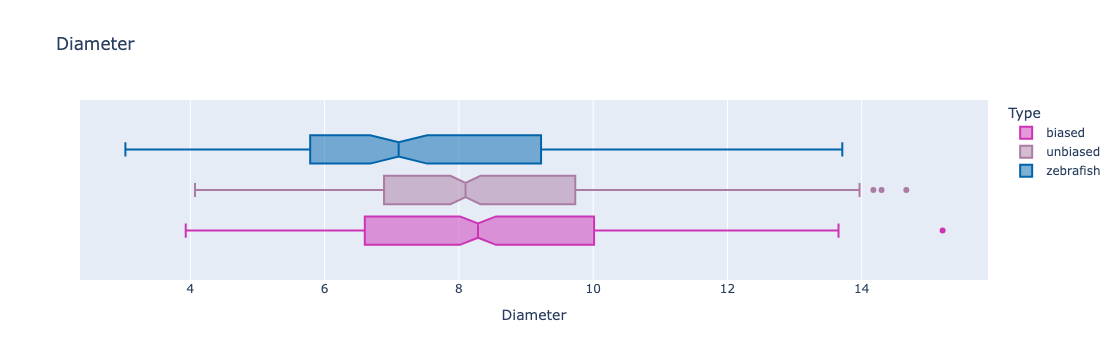

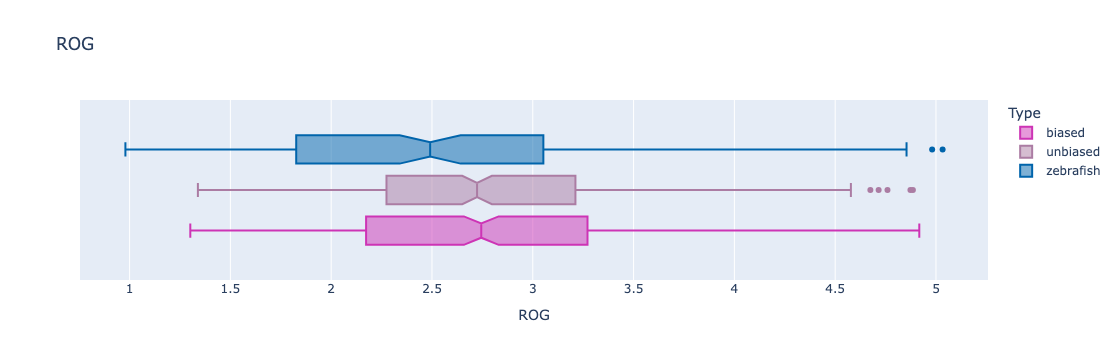

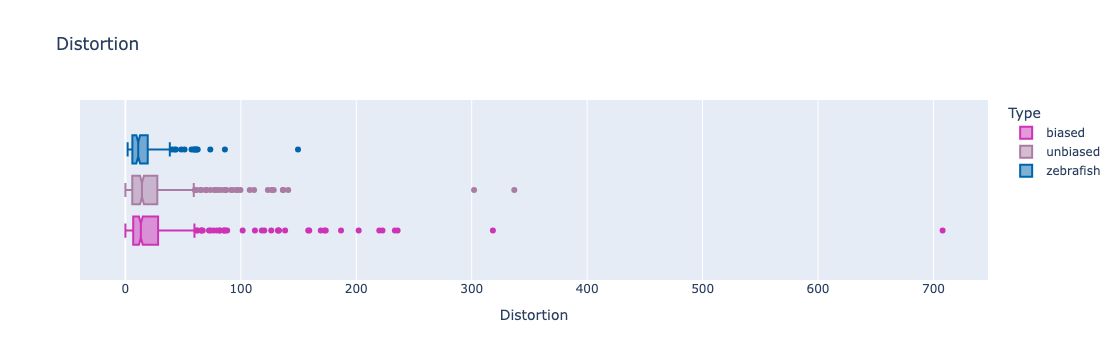

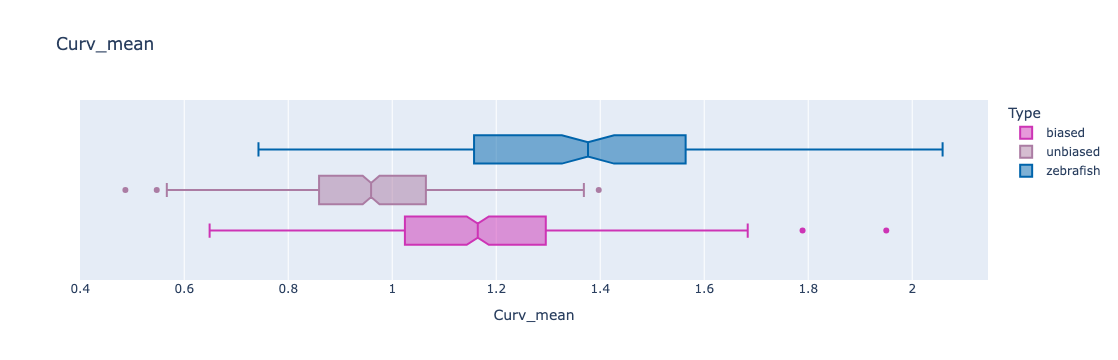

In [36]:
import plotly.express as px

for col in ["Diameter", "ROG", "Distortion", "Curv_mean"]:
    fig = px.box(
        Df_baseline,
        x=col,
        color="Type",
        notched=True,
        title=col,
        color_discrete_sequence=COLOR_PALETTE
    )
    fig.show()

In [54]:
def robust_barplot(df, column):

    results = []

    for label in ["unbiased", "biased", "zebrafish"]:
        data = df[df["Type"] == label][column].values
        
        # clean
        data = data[np.isfinite(data)]

        median = np.median(data)

        # ✅ robust CI via quantiles (THIS FIXES EVERYTHING)
        q_low = np.percentile(data, 25)
        q_high = np.percentile(data, 75)

        ci_low = median - q_low
        ci_high = q_high - median

        results.append((label, median, ci_low, ci_high))

    out = pd.DataFrame(results, columns=["Type", column, "CI_low", "CI_high"])

    print(out)  # debugging

    fig = px.bar(
        out,
        x="Type",
        y=column,
        color="Type",
        error_y="CI_high",
        error_y_minus="CI_low",
        color_discrete_map={
            'unbiased': '#cd34b5',
            'biased': '#0064ab',
            'zebrafish': '#ab7ca3'
        }
    )

    fig.update_layout(showlegend=False, width=500, height=500)
    fig.write_image("{}.png".format(column))
    fig.show()

        Type  Diameter    CI_low   CI_high
0   unbiased  8.098757  1.210360  1.628825
1     biased  8.284677  1.678743  1.724698
2  zebrafish  7.103300  1.316723  2.097333


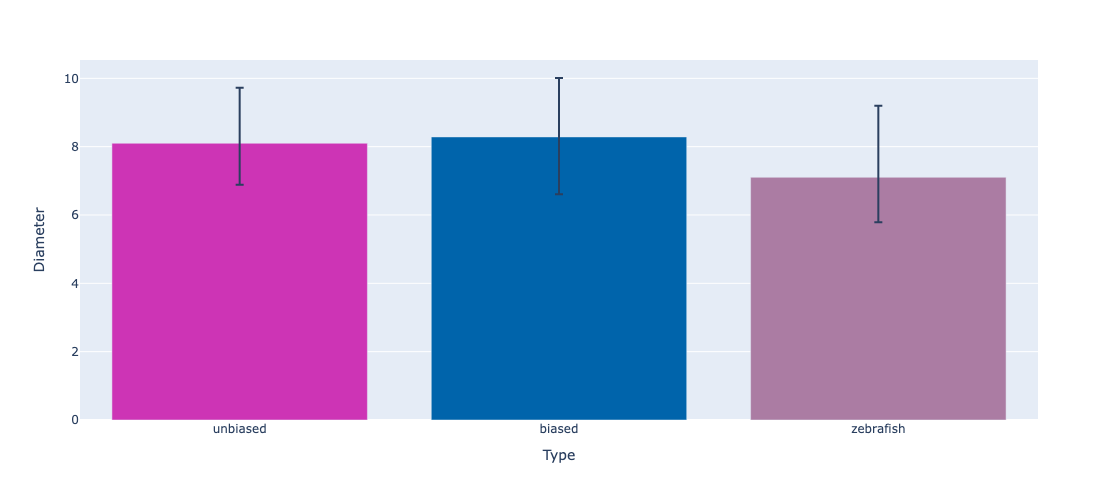

        Type       ROG    CI_low   CI_high
0   unbiased  2.723623  0.448946  0.487572
1     biased  2.744383  0.571111  0.525463
2  zebrafish  2.490995  0.651387  0.556076


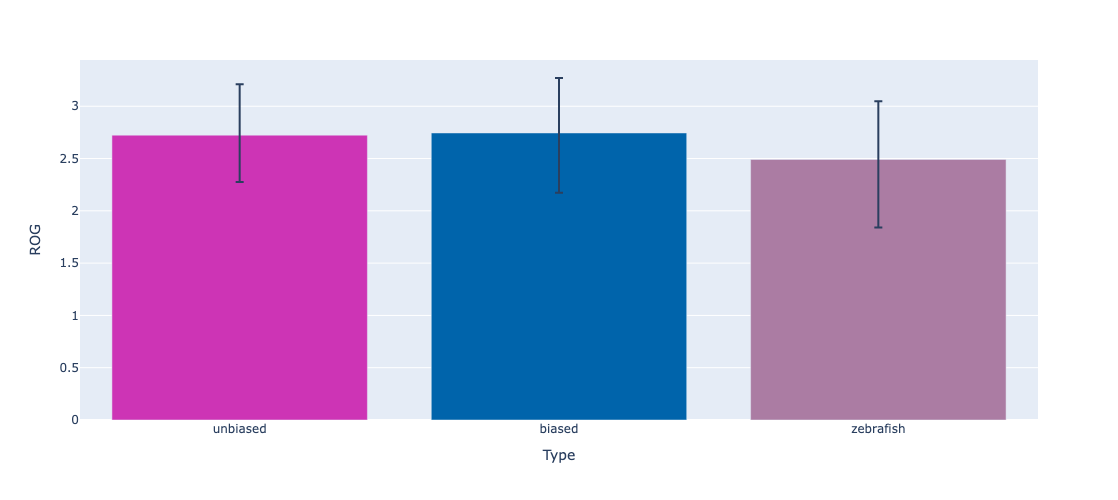

        Type  Distortion    CI_low    CI_high
0   unbiased   14.358400  8.366269  13.257504
1     biased   13.391254  6.619310  14.900187
2  zebrafish   11.096085  5.045418   8.151149


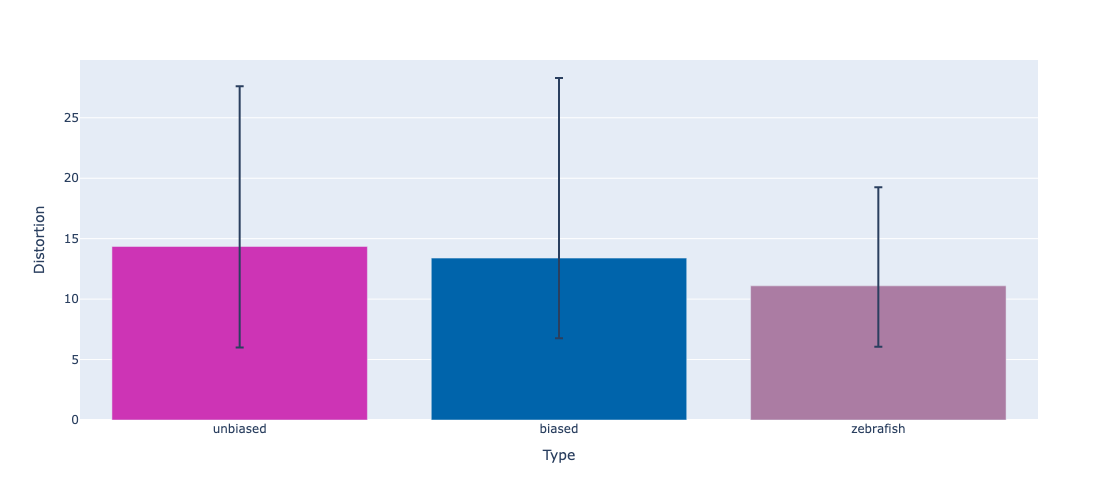

        Type  Curv_mean    CI_low   CI_high
0   unbiased   0.959362  0.099546  0.105177
1     biased   1.164547  0.140086  0.129717
2  zebrafish   1.376508  0.217633  0.187404


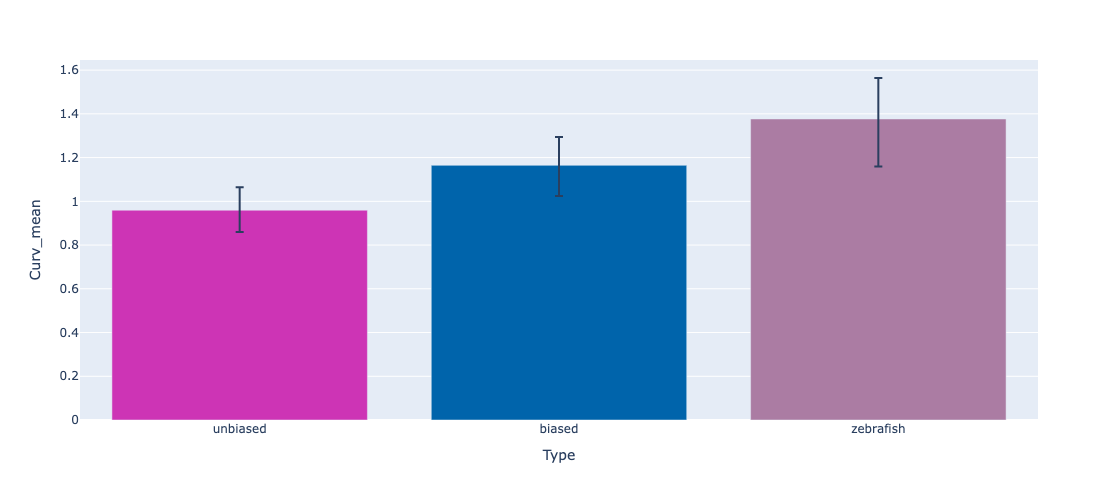

In [55]:

for col in ["Diameter", "ROG", "Distortion", "Curv_mean"]:
    robust_barplot(Df_baseline, col)


In [50]:
from scipy.stats import mannwhitneyu, kstest
import numpy as np

B = Df_baseline.loc[Df_baseline['Type'] == 'biased']
U = Df_baseline.loc[Df_baseline['Type'] == 'unbiased']
Z = Df_baseline.loc[Df_baseline['Type'] == 'zebrafish']

BB, UU, ZZ = [], [], []

# --- baseline features ---
for M in ['Diameter','ROG','Curv_mean']:
    
    for el in B[M]:
        if np.isfinite(el):
            BB.append(el)
    for el in U[M]:
        if np.isfinite(el):
            UU.append(el)
    for el in Z[M]:
        if np.isfinite(el):
            ZZ.append(el)


# --- distortion ---
M = 'Distortion'

for el in B[M]:
    if np.isfinite(el):
        BB.append(el)

for el in U[M]:
    if np.isfinite(el):
        UU.append(el)

for el in Z[M]:
    if np.isfinite(el):
        ZZ.append(el)


# --- stats ---
M_mat, N_mat = np.zeros((3,3)), np.zeros((3,3))
ALL = [UU, BB, ZZ]

for a in ALL:
    for b in ALL:
        i, j = ALL.index(a), ALL.index(b)
        M_mat[i,j] = mannwhitneyu(a, b, alternative='two-sided')[1]
        N_mat[i,j] = kstest(a, b)[1]

print("Mann-Whitney:\n", M_mat)
print("\nKS:\n", N_mat)

Mann-Whitney:
 [[1.         0.05744214 0.86752041]
 [0.05744214 1.         0.43220015]
 [0.86752041 0.43220015 1.        ]]

KS:
 [[1.00000000e+00 4.91123462e-09 7.94513402e-11]
 [4.91123462e-09 1.00000000e+00 9.52375152e-04]
 [7.94513402e-11 9.52375152e-04 1.00000000e+00]]


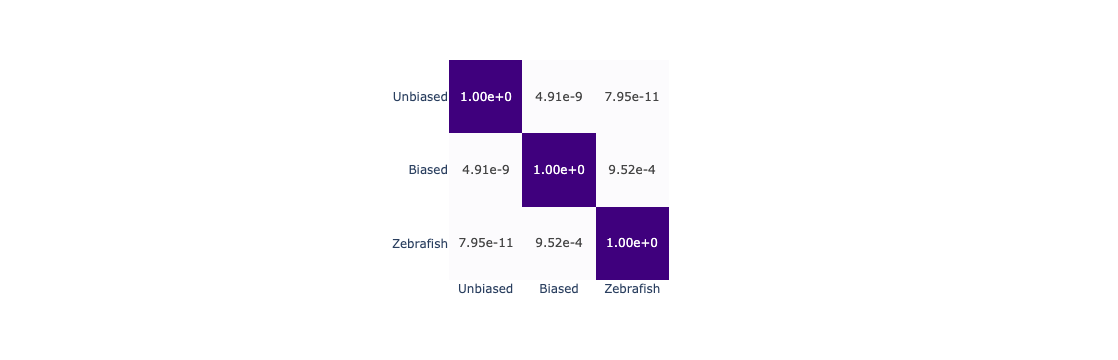

In [59]:
fig = px.imshow(
    N_mat,
    color_continuous_scale='purples',
    text_auto='.2e'
)

fig.update_coloraxes(showscale=False)

fig.update_layout(
    yaxis=dict(
        tickmode='array',
        tickvals=[0,1,2],
        ticktext=['Unbiased','Biased','Zebrafish']
    ),
    xaxis=dict(
        tickmode='array',
        tickvals=[0,1,2],
        ticktext=['Unbiased','Biased','Zebrafish']
    )
)

fig.show()
fig.write_image('baseline_KS.png')

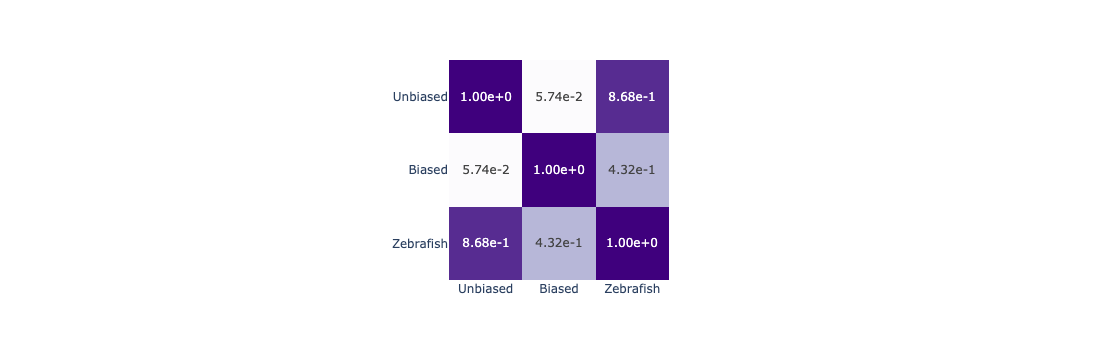

In [60]:
fig = px.imshow(
    M_mat,
    color_continuous_scale='purples',
    text_auto='.2e'
)

fig.update_coloraxes(showscale=False)

fig.update_layout(
    yaxis=dict(
        tickmode='array',
        tickvals=[0,1,2],
        ticktext=['Unbiased','Biased','Zebrafish']
    ),
    xaxis=dict(
        tickmode='array',
        tickvals=[0,1,2],
        ticktext=['Unbiased','Biased','Zebrafish']
    )
)
fig.write_image('baseline_MW.png')
fig.show()